In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch
import numpy as np
import random
from pathlib import Path
seed = 2

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
base_path = Path("data")

df14_raw = pd.read_csv(base_path / "sber140313.txt", header=None, encoding='cp1251')
df15_raw = pd.read_csv(base_path / "sber150313.txt", header=None, encoding='cp1251')
df16_raw = pd.read_csv(base_path / "sber160113.txt", header=None, encoding='cp1251')

print("14:", df14_raw.shape)
print("15:", df15_raw.shape)
print("16:", df16_raw.shape)

14: (49004, 16)
15: (52142, 16)
16: (39105, 16)


In [4]:
print("14 columns:", df14_raw.columns.tolist())
print(df14_raw.iloc[0])
print(df14_raw.iloc[1])

print("15 columns:", df15_raw.columns.tolist())
print(df15_raw.iloc[0])

print("16 columns:", df16_raw.columns.tolist())
print(df16_raw.iloc[0])

14 columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
0     2050306062
1       09:59:59
2       Сбербанк
3       А1-Акции
4           SBER
5         104.43
6            0.0
7            100
8       104430.0
9            NaN
10           NaN
11             0
12           NaN
13           NaN
14            T0
15             B
Name: 0, dtype: object
0     2050306063
1       09:59:59
2       Сбербанк
3       А1-Акции
4           SBER
5         104.43
6            0.0
7             18
8        18797.4
9            NaN
10           NaN
11             0
12           NaN
13           NaN
14            T0
15             B
Name: 1, dtype: object
15 columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
0     2052306083
1       09:59:59
2       Сбербанк
3       А1-Акции
4           SBER
5          105.6
6            0.0
7              9
8         9504.0
9            NaN
10           NaN
11             0
12           NaN
13           NaN
14            T0
15             B
Name

In [5]:
def prepare_day(df_raw, date_str):
    df = df_raw[[1, 5, 7, 15]].copy()
    df.columns = ['time', 'price', 'volume', 'side']

    df['time'] = df['time'].astype(str)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
    df['side'] = df['side'].astype(str)

    df = df.dropna(subset=['time', 'price', 'volume'])
    df = df.sort_values('time').reset_index(drop=True)

    df_agg = df.groupby('time', as_index=False).agg({
        'price': 'last',
        'volume': 'sum'
    })

    df_agg['datetime'] = pd.to_datetime(date_str + ' ' + df_agg['time'])
    df_agg = df_agg.sort_values('datetime').set_index('datetime')

    return df_agg

In [6]:
df14_agg = prepare_day(df14_raw, '2013-03-14')
df15_agg = prepare_day(df15_raw, '2013-03-15')
df16_agg = prepare_day(df16_raw, '2013-03-16')

print("df14_agg:", df14_agg.shape)
print("df15_agg:", df15_agg.shape)
print("df16_agg:", df16_agg.shape)

display(df14_agg.head())
display(df15_agg.head())
display(df16_agg.head())

df14_agg: (12164, 3)
df15_agg: (12487, 3)
df16_agg: (11142, 3)


,time,price,volume
datetime,,,
2013-03-14 09:59:59,09:59:59,104.43,6733
2013-03-14 10:00:00,10:00:00,104.42,1338
2013-03-14 10:00:01,10:00:01,104.30,785
2013-03-14 10:00:02,10:00:02,104.32,893
2013-03-14 10:00:03,10:00:03,104.28,3943


,time,price,volume
datetime,,,
2013-03-15 09:59:59,09:59:59,105.60,9714
2013-03-15 10:00:00,10:00:00,105.65,465
2013-03-15 10:00:01,10:00:01,105.68,2602
2013-03-15 10:00:02,10:00:02,105.60,2300
2013-03-15 10:00:03,10:00:03,105.50,420


,time,price,volume
datetime,,,
2013-03-16 09:59:59,09:59:59,99.85,2580
2013-03-16 10:00:01,10:00:01,99.86,361
2013-03-16 10:00:02,10:00:02,99.87,1736
2013-03-16 10:00:03,10:00:03,99.93,835
2013-03-16 10:00:04,10:00:04,99.99,20


# Построение признаков


In [7]:
def add_features(df_agg):
    df = df_agg.copy()

    lags = [10, 20, 40, 80, 160, 320]

    # diff
    for lag in lags:
        df[f'diff_{lag}'] = df['price'] - df['price'].shift(lag)

    for lag in [10, 20, 40]:
        df[f'return_{lag}'] = (
            df['price'] - df['price'].shift(lag)
        ) / df['price'].shift(lag)

    feature_cols = (
        [f'diff_{lag}' for lag in lags] +
        [f'return_{lag}' for lag in [10, 20, 40]]
    )

    df_model = df.dropna().copy()
    return df_model, feature_cols

In [8]:
df14_model, feature_cols = add_features(df14_agg)
df15_model, _ = add_features(df15_agg)
df16_model, _ = add_features(df16_agg)

print("feature_cols:", feature_cols)
print("df14_model:", df14_model.shape)
print("df15_model:", df15_model.shape)
print("df16_model:", df16_model.shape)

feature_cols: ['diff_10', 'diff_20', 'diff_40', 'diff_80', 'diff_160', 'diff_320', 'return_10', 'return_20', 'return_40']
df14_model: (11844, 12)
df15_model: (12167, 12)
df16_model: (10822, 12)


# Разметка минимумов и максимумов

In [9]:
def mark_turning_points(df_model):
    df = df_model.copy()

    df['is_min'] = 0
    df['is_max'] = 0

    prices = df['price'].values

    for i in range(3, len(df) - 10):
        current = prices[i]
        past = prices[i - 3:i]
        future = prices[i + 1:i + 11]

        if current < past.min() and current < future.min():
            df.iloc[i, df.columns.get_loc('is_min')] = 1

        if current > past.max() and current > future.max():
            df.iloc[i, df.columns.get_loc('is_max')] = 1

    return df

In [10]:
df14_model = mark_turning_points(df14_model)
df15_model = mark_turning_points(df15_model)
df16_model = mark_turning_points(df16_model)

print("14: min =", df14_model['is_min'].sum(), "max =", df14_model['is_max'].sum())
print("15: min =", df15_model['is_min'].sum(), "max =", df15_model['is_max'].sum())
print("16: min =", df16_model['is_min'].sum(), "max =", df16_model['is_max'].sum())

14: min = 242 max = 271
15: min = 202 max = 259
16: min = 167 max = 205


Зафиксируем
14 - train
15 - val
16 - test

In [11]:
train_df = df14_model.copy()
val_df = df15_model.copy()
test_df = df16_model.copy()

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (11844, 14)
val: (12167, 14)
test: (10822, 14)


In [12]:
X_train = train_df[feature_cols].values.astype(np.float32)
X_val = val_df[feature_cols].values.astype(np.float32)
X_test = test_df[feature_cols].values.astype(np.float32)

y_min_train = train_df['is_min'].values.astype(np.float32)
y_min_val = val_df['is_min'].values.astype(np.float32)
y_min_test = test_df['is_min'].values.astype(np.float32)

y_max_train = train_df['is_max'].values.astype(np.float32)
y_max_val = val_df['is_max'].values.astype(np.float32)
y_max_test = test_df['is_max'].values.astype(np.float32)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_min_train mean:", y_min_train.mean())
print("y_min_val mean:", y_min_val.mean())
print("y_min_test mean:", y_min_test.mean())

print("y_max_train mean:", y_max_train.mean())
print("y_max_val mean:", y_max_val.mean())
print("y_max_test mean:", y_max_test.mean())

X_train: (11844, 9)
X_val: (12167, 9)
X_test: (10822, 9)
y_min_train mean: 0.020432286
y_min_val mean: 0.016602285
y_min_test mean: 0.015431528
y_max_train mean: 0.022880783
y_max_val mean: 0.021287087
y_max_test mean: 0.018942894


In [13]:
from sklearn.preprocessing import StandardScaler

print("До масштабирования:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("\nПосле StandardScaler:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nПроверка train:")
print("mean (первые 5):", X_train.mean(axis=0)[:5])
print("std  (первые 5):", X_train.std(axis=0)[:5])

print("\nДоли класса min:")
print("train:", y_min_train.mean())
print("val:", y_min_val.mean())
print("test:", y_min_test.mean())

До масштабирования:
X_train: (11844, 9)
X_val: (12167, 9)
X_test: (10822, 9)

После StandardScaler:
X_train: (11844, 9)
X_val: (12167, 9)
X_test: (10822, 9)

Проверка train:
mean (первые 5): [ 3.8649417e-09 -1.9324709e-09 -6.4415691e-09 -3.8649417e-09
 -1.5459767e-08]
std  (первые 5): [1. 1. 1. 1. 1.]

Доли класса min:
train: 0.020432286
val: 0.016602285
test: 0.015431528


# Обучение

In [14]:
import torch
import copy
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_min_train_t = torch.tensor(y_min_train, dtype=torch.float32).view(-1, 1)
y_min_val_t = torch.tensor(y_min_val, dtype=torch.float32).view(-1, 1)
y_min_test_t = torch.tensor(y_min_test, dtype=torch.float32).view(-1, 1)

cpu


In [16]:
class_counts = np.bincount(y_min_train.astype(int))
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[y_min_train.astype(int)]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_min_train_t),
    batch_size=256,
    sampler=sampler
)

print("class_counts:", class_counts)
print("class_weights:", class_weights)

class_counts: [11602   242]
class_weights: [8.61920359e-05 4.13223140e-03]


In [17]:
def find_best_threshold(y_true, probs):
    rows = []

    for thr in np.arange(0.20, 0.82, 0.02):
        preds = (probs >= thr).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true,
            preds,
            average='binary',
            zero_division=0
        )

        rows.append((thr, precision, recall, f1, preds.mean()))

    best = max(rows, key=lambda x: (x[3], x[1], x[2]))
    return best

# Сравнение архитектур моделей

In [18]:
models_dict = {
    "32-16": lambda: nn.Sequential(
        nn.Linear(X_train.shape[1], 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ),

    "64-32": lambda: nn.Sequential(
        nn.Linear(X_train.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ),

    "32-16-8": lambda: nn.Sequential(
        nn.Linear(X_train.shape[1], 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    ),

    "64-32-16": lambda: nn.Sequential(
        nn.Linear(X_train.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )
}

In [19]:
def safe_corrcoef(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
        return 0.0

    return float(np.corrcoef(y_true, y_pred)[0, 1])


def get_architecture_info(model):
    linear_layers = [m for m in model if isinstance(m, nn.Linear)]

    hidden_sizes = [layer.out_features for layer in linear_layers[:-1]]
    n_layers = len(linear_layers)

    # число связей = только веса, без bias
    n_connections = sum(layer.in_features * layer.out_features for layer in linear_layers)

    return hidden_sizes, n_layers, n_connections


def format_hidden_sizes(hidden_sizes):
    return "-".join(map(str, hidden_sizes))

# Автоматическое обучение для минимумов

In [20]:
results_min = []
saved_min_models = {}

for name, model_fn in models_dict.items():
    print(f"\nModel: {name}")

    model_min = model_fn().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model_min.parameters(), lr=0.001)

    best_f1 = -1
    best_thr = 0.5
    best_state = None   # <-- добавили

    for epoch in range(50):
        model_min.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model_min(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        # validation
        model_min.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model_min(X_val_t.to(device))).cpu().numpy().reshape(-1)
            val_true = y_min_val.astype(int)

        # подбор threshold
        for thr in np.arange(0.2, 0.8, 0.05):
            preds = (val_probs >= thr).astype(int)

            precision, recall, f1, _ = precision_recall_fscore_support(
                val_true,
                preds,
                average='binary',
                zero_division=0
            )

            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
                best_state = copy.deepcopy(model_min.state_dict())   # <-- добавили

    # загружаем лучшую версию модели
    model_min.load_state_dict(best_state)

    saved_min_models[name] = {
        "model": copy.deepcopy(model_min).to(device),
        "threshold": best_thr,
        "best_f1": best_f1
    }

    model_min.eval()
    with torch.no_grad():
        train_probs = torch.sigmoid(model_min(X_train_t.to(device))).cpu().numpy().reshape(-1)
        val_probs   = torch.sigmoid(model_min(X_val_t.to(device))).cpu().numpy().reshape(-1)
        test_probs  = torch.sigmoid(model_min(X_test_t.to(device))).cpu().numpy().reshape(-1)

    # корреляции
    train_corr = safe_corrcoef(y_min_train, train_probs)
    val_corr   = safe_corrcoef(y_min_val, val_probs)
    test_corr  = safe_corrcoef(y_min_test, test_probs)

    # информация об архитектуре
    hidden_sizes, n_layers, n_connections = get_architecture_info(model_min)

    results_min.append({
        "Название сети": f"FFN-{name}",
        "Размер (число нейронов)": format_hidden_sizes(hidden_sizes),
        "Число слоев": n_layers,
        "Число связей": n_connections,
        "Корреляция train": train_corr,
        "Корреляция val": val_corr,
        "Корреляция test": test_corr,
        "Лучший F1": best_f1,
        "Порог": best_thr
    })

table2 = pd.DataFrame(results_min).sort_values(
    ["Корреляция val", "Лучший F1"], ascending=False
).reset_index(drop=True)

table2.round(4)


Model: 32-16

Model: 64-32

Model: 32-16-8

Model: 64-32-16


,Название сети,Размер (число нейронов),Число слоев,Число связей,Корреляция train,Корреляция val,Корреляция test,Лучший F1,Порог
0,FFN-32-16,32-16,3,816,0.1566,0.1031,0.1111,0.0799,0.75
1,FFN-64-32,64-32,3,2656,0.1219,0.0995,0.1003,0.0846,0.80
2,FFN-64-32-16,64-32-16,4,3152,0.1252,0.0961,0.1096,0.0813,0.75
3,FFN-32-16-8,32-16-8,4,936,0.1101,0.0841,0.0898,0.0774,0.65


In [21]:
table2_short = table2[[
    "Название сети",
    "Размер (число нейронов)",
    "Число связей",
    "Корреляция val"
]].copy()

table2_short = table2_short.rename(columns={
    "Корреляция val": "Корреляция между входом и выходом"
})

table2_short.round(4)

,Название сети,Размер (число нейронов),Число связей,Корреляция между входом и выходом
0,FFN-32-16,32-16,816,0.1031
1,FFN-64-32,64-32,2656,0.0995
2,FFN-64-32-16,64-32-16,3152,0.0961
3,FFN-32-16-8,32-16-8,936,0.0841


# Автоматическое обучение для максимумов

In [22]:
y_max_train = train_df['is_max'].values.astype(np.float32)
y_max_val = val_df['is_max'].values.astype(np.float32)
y_max_test = test_df['is_max'].values.astype(np.float32)

y_max_train_t = torch.tensor(y_max_train, dtype=torch.float32).view(-1, 1)
y_max_val_t = torch.tensor(y_max_val, dtype=torch.float32).view(-1, 1)
y_max_test_t = torch.tensor(y_max_test, dtype=torch.float32).view(-1, 1)

In [23]:
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

train_dataset_max = TensorDataset(X_train_t, y_max_train_t)
val_dataset_max   = TensorDataset(X_val_t, y_max_val_t)

# балансировка классов для максимумов
class_counts = np.bincount(y_max_train.astype(int))
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[y_max_train.astype(int)]

sampler_max = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_max = DataLoader(
    train_dataset_max,
    batch_size=256,
    sampler=sampler_max
)

val_loader_max = DataLoader(
    val_dataset_max,
    batch_size=256,
    shuffle=False
)

results_max = []
saved_max_models = {}

for name, model_fn in models_dict.items():
    print(f"\nModel: {name}")

    model_max = model_fn().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model_max.parameters(), lr=0.001)

    best_f1 = -1
    best_thr = 0.5
    best_state = None   # <-- добавили

    for epoch in range(50):
        model_max.train()

        for xb, yb in train_loader_max:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model_max(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        # validation
        model_max.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model_max(X_val_t.to(device))).cpu().numpy().reshape(-1)
            val_true = y_max_val.astype(int)

        # подбор threshold
        for thr in np.arange(0.20, 0.82, 0.02):
            preds = (val_probs >= thr).astype(int)

            precision, recall, f1, _ = precision_recall_fscore_support(
                val_true,
                preds,
                average='binary',
                zero_division=0
            )

            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
                best_state = copy.deepcopy(model_max.state_dict())

    # загружаем лучшую версию модели
    model_max.load_state_dict(best_state)

    saved_max_models[name] = {
        "model": copy.deepcopy(model_max).to(device),
        "threshold": best_thr,
        "best_f1": best_f1
    }

    model_max.eval()
    with torch.no_grad():
        train_probs = torch.sigmoid(model_max(X_train_t.to(device))).cpu().numpy().reshape(-1)
        val_probs   = torch.sigmoid(model_max(X_val_t.to(device))).cpu().numpy().reshape(-1)
        test_probs  = torch.sigmoid(model_max(X_test_t.to(device))).cpu().numpy().reshape(-1)

    # корреляции
    train_corr = safe_corrcoef(y_max_train, train_probs)
    val_corr   = safe_corrcoef(y_max_val, val_probs)
    test_corr  = safe_corrcoef(y_max_test, test_probs)

    # информация об архитектуре
    hidden_sizes, n_layers, n_connections = get_architecture_info(model_max)

    results_max.append({
        "Название сети": f"FFN-{name}",
        "Размер (число нейронов)": format_hidden_sizes(hidden_sizes),
        "Число слоев": n_layers,
        "Число связей": n_connections,
        "Корреляция train": train_corr,
        "Корреляция val": val_corr,
        "Корреляция test": test_corr,
        "Лучший F1": best_f1,
        "Порог": best_thr
    })

table3 = pd.DataFrame(results_max).sort_values(
    ["Корреляция val", "Лучший F1"], ascending=False
).reset_index(drop=True)

table3.round(4)


Model: 32-16

Model: 64-32

Model: 32-16-8

Model: 64-32-16


,Название сети,Размер (число нейронов),Число слоев,Число связей,Корреляция train,Корреляция val,Корреляция test,Лучший F1,Порог
0,FFN-32-16-8,32-16-8,4,936,0.1178,0.1133,0.0927,0.1089,0.62
1,FFN-32-16,32-16,3,816,0.1209,0.1120,0.0934,0.1128,0.62
2,FFN-64-32,64-32,3,2656,0.1232,0.1117,0.0942,0.1057,0.64
3,FFN-64-32-16,64-32-16,4,3152,0.2408,0.1021,0.0827,0.1125,0.80


In [24]:
table3_short = table3[[
    "Название сети",
    "Размер (число нейронов)",
    "Число связей",
    "Корреляция val"
]].copy()

table3_short = table3_short.rename(columns={
    "Корреляция val": "Корреляция между входом и выходом"
})

table3_short.round(4)

,Название сети,Размер (число нейронов),Число связей,Корреляция между входом и выходом
0,FFN-32-16-8,32-16-8,936,0.1133
1,FFN-32-16,32-16,816,0.1120
2,FFN-64-32,64-32,2656,0.1117
3,FFN-64-32-16,64-32-16,3152,0.1021


# Прогноз цены на основе обращённого Медленного %K.

По условию обучаемся на первой половине 14-го дня, валидируемся на второй половине 14-го дня и проверяем модель на следующем торговом дне.

In [25]:
df14_k = df14_agg.copy()
df15_k = df15_agg.copy()
df16_k = df16_agg.copy()

midpoint_14 = len(df14_k) // 2
print("14 full:", df14_k.shape)
print("14 train half:", df14_k.iloc[:midpoint_14].shape)
print("14 val half:", df14_k.iloc[midpoint_14:].shape)
print("15 test:", df15_k.shape)
print("16 holdout:", df16_k.shape)

14 full: (12164, 3)
14 train half: (6082, 3)
14 val half: (6082, 3)
15 test: (12487, 3)
16 holdout: (11142, 3)


In [26]:
def build_k_features(df_agg, lags=None):
    if lags is None:
        lags = [10, 20, 40, 80, 160, 320]

    df = df_agg.copy()

    for lag in lags:
        df[f'diff_{lag}'] = df['price'] - df['price'].shift(lag)

    feature_cols = [f'diff_{lag}' for lag in lags]
    return df, feature_cols

In [27]:
def add_slow_k_target(df, price_col='price', window=14, smooth=3):
    df = df.copy()

    rolling_low = df[price_col].rolling(window).min()
    rolling_high = df[price_col].rolling(window).max()

    fast_k = 100 * (df[price_col] - rolling_low) / (rolling_high - rolling_low + 1e-8)
    slow_k = fast_k.rolling(smooth).mean()

    df['slow_k'] = slow_k
    df['inv_slow_k'] = 100 - slow_k

    return df

In [28]:
df14_k, feature_cols_k = build_k_features(df14_k)
df15_k, _ = build_k_features(df15_k)
df16_k, _ = build_k_features(df16_k)

df14_k = add_slow_k_target(df14_k)
df15_k = add_slow_k_target(df15_k)
df16_k = add_slow_k_target(df16_k)

df14_k = df14_k.dropna().copy()
df15_k = df15_k.dropna().copy()
df16_k = df16_k.dropna().copy()

print("df14_k:", df14_k.shape)
print("df15_k:", df15_k.shape)
print("df16_k:", df16_k.shape)

print(feature_cols_k)
df14_k[['price', 'slow_k', 'inv_slow_k']].head()

df14_k: (11844, 11)
df15_k: (12167, 11)
df16_k: (10822, 11)
['diff_10', 'diff_20', 'diff_40', 'diff_80', 'diff_160', 'diff_320']


,price,slow_k,inv_slow_k
datetime,,,
2013-03-14 10:09:37,104.60,11.111107,88.888893
2013-03-14 10:09:38,104.60,0.000000,100.000000
2013-03-14 10:09:39,104.60,0.000000,100.000000
2013-03-14 10:09:40,104.63,33.333322,66.666678
2013-03-14 10:09:44,104.60,33.333322,66.666678


In [29]:
midpoint_14 = len(df14_k) // 2

train_k_df = df14_k.iloc[:midpoint_14].copy()
val_k_df = df14_k.iloc[midpoint_14:].copy()
test_k_df = df15_k.copy()
holdout_k_df = df16_k.copy()

print("train_k_df:", train_k_df.shape)
print("val_k_df:", val_k_df.shape)
print("test_k_df:", test_k_df.shape)
print("holdout_k_df:", holdout_k_df.shape)

train_k_df: (5922, 11)
val_k_df: (5922, 11)
test_k_df: (12167, 11)
holdout_k_df: (10822, 11)


In [30]:
Xk_train = train_k_df[feature_cols_k].values.astype(np.float32)
Xk_val = val_k_df[feature_cols_k].values.astype(np.float32)
Xk_test = test_k_df[feature_cols_k].values.astype(np.float32)
Xk_holdout = holdout_k_df[feature_cols_k].values.astype(np.float32)

yk_train = train_k_df['inv_slow_k'].values.astype(np.float32)
yk_val = val_k_df['inv_slow_k'].values.astype(np.float32)
yk_test = test_k_df['inv_slow_k'].values.astype(np.float32)
yk_holdout = holdout_k_df['inv_slow_k'].values.astype(np.float32)

print(Xk_train.shape, Xk_val.shape, Xk_test.shape, Xk_holdout.shape)
print(yk_train.shape, yk_val.shape, yk_test.shape, yk_holdout.shape)

(5922, 6) (5922, 6) (12167, 6) (10822, 6)
(5922,) (5922,) (12167,) (10822,)


In [31]:
def normalize_rows_only(X):
    norms = np.linalg.norm(X, axis=1)
    mask = norms > 0

    X_norm = X[mask] / norms[mask][:, None]
    return X_norm, mask

In [32]:
Xk_train, mask_train_k = normalize_rows_only(Xk_train)
Xk_val, mask_val_k = normalize_rows_only(Xk_val)
Xk_test, mask_test_k = normalize_rows_only(Xk_test)
Xk_holdout, mask_holdout_k = normalize_rows_only(Xk_holdout)

yk_train = yk_train[mask_train_k]
yk_val = yk_val[mask_val_k]
yk_test = yk_test[mask_test_k]
yk_holdout = yk_holdout[mask_holdout_k]

print("After row normalization:")
print(Xk_train.shape, Xk_val.shape, Xk_test.shape, Xk_holdout.shape)
print(yk_train[:5])

After row normalization:
(5922, 6) (5922, 6) (12166, 6) (10820, 6)
[ 88.88889 100.      100.       66.66668  66.66668]


In [33]:
Xk_train_t = torch.tensor(Xk_train, dtype=torch.float32)
Xk_val_t = torch.tensor(Xk_val, dtype=torch.float32)
Xk_test_t = torch.tensor(Xk_test, dtype=torch.float32)
Xk_holdout_t = torch.tensor(Xk_holdout, dtype=torch.float32)

yk_train_t = torch.tensor(yk_train, dtype=torch.float32).view(-1, 1)
yk_val_t = torch.tensor(yk_val, dtype=torch.float32).view(-1, 1)
yk_test_t = torch.tensor(yk_test, dtype=torch.float32).view(-1, 1)
yk_holdout_t = torch.tensor(yk_holdout, dtype=torch.float32).view(-1, 1)

print(Xk_train_t.shape, yk_train_t.shape)

torch.Size([5922, 6]) torch.Size([5922, 1])


In [34]:
from torch.utils.data import TensorDataset, DataLoader

train_loader_k = DataLoader(
    TensorDataset(Xk_train_t, yk_train_t),
    batch_size=256,
    shuffle=True
)

val_loader_k = DataLoader(
    TensorDataset(Xk_val_t, yk_val_t),
    batch_size=256,
    shuffle=False
)

In [35]:
models_k = {
    "32-16": lambda: nn.Sequential(
        nn.Linear(Xk_train.shape[1], 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ),

    "64-32": lambda: nn.Sequential(
        nn.Linear(Xk_train.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ),

    "32-16-8": lambda: nn.Sequential(
        nn.Linear(Xk_train.shape[1], 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    ),

    "64-32-16": lambda: nn.Sequential(
        nn.Linear(Xk_train.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ),
}

In [36]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [37]:
def safe_corrcoef(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
        return 0.0

    return float(np.corrcoef(y_true, y_pred)[0, 1])

In [38]:
results_k = []
saved_k_models = {}

for name, model_fn in models_k.items():
    print(f"\nModel: {name}")

    model_k = model_fn().to(device)

    criterion_k = nn.MSELoss()
    optimizer_k = torch.optim.Adam(model_k.parameters(), lr=0.001, weight_decay=1e-4)

    best_state = None
    best_val_loss = float('inf')
    patience = 15
    patience_left = patience

    for epoch in range(100):
        model_k.train()
        train_losses = []

        for xb, yb in train_loader_k:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_k.zero_grad()
            preds = model_k(xb)
            loss = criterion_k(preds, yb)
            loss.backward()
            optimizer_k.step()

            train_losses.append(loss.item())

        model_k.eval()
        with torch.no_grad():
            val_preds = model_k(Xk_val_t.to(device))
            val_loss = criterion_k(val_preds, yk_val_t.to(device)).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_k.state_dict())
            patience_left = patience
        else:
            patience_left -= 1

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d} | "
                f"train_loss={np.mean(train_losses):.4f} | "
                f"val_loss={val_loss:.4f}"
            )

        if patience_left == 0:
            print("Early stopping")
            break

    model_k.load_state_dict(best_state)
    model_k.eval()

    saved_k_models[name] = {
        "model": copy.deepcopy(model_k).to(device)
    }

    with torch.no_grad():
        train_pred = model_k(Xk_train_t.to(device)).cpu().numpy().reshape(-1)
        val_pred = model_k(Xk_val_t.to(device)).cpu().numpy().reshape(-1)
        test_pred = model_k(Xk_test_t.to(device)).cpu().numpy().reshape(-1)
        holdout_pred = model_k(Xk_holdout_t.to(device)).cpu().numpy().reshape(-1)

    train_corr = safe_corrcoef(yk_train, train_pred)
    val_corr = safe_corrcoef(yk_val, val_pred)
    test_corr = safe_corrcoef(yk_test, test_pred)
    holdout_corr = safe_corrcoef(yk_holdout, holdout_pred)

    results_k.append({
        "model": name,
        "layers": len([m for m in model_k if isinstance(m, nn.Linear)]),
        "n_params": count_parameters(model_k),
        "best_val_loss": best_val_loss,
        "train_corr": train_corr,
        "val_corr": val_corr,
        "test_corr": test_corr,
        "holdout_corr": holdout_corr
    })

results_k_df = pd.DataFrame(results_k).sort_values("val_corr", ascending=False)


Model: 32-16
Epoch   0 | train_loss=4104.5279 | val_loss=3565.5957
Epoch  10 | train_loss=1212.3291 | val_loss=878.0667
Epoch  20 | train_loss=725.3511 | val_loss=664.8698
Epoch  30 | train_loss=698.3425 | val_loss=645.9216
Epoch  40 | train_loss=686.2401 | val_loss=635.2316
Epoch  50 | train_loss=670.1691 | val_loss=628.9901
Epoch  60 | train_loss=665.8672 | val_loss=621.5809
Epoch  70 | train_loss=657.9110 | val_loss=617.1393
Epoch  80 | train_loss=655.0427 | val_loss=613.8932
Epoch  90 | train_loss=641.1726 | val_loss=607.6779

Model: 64-32
Epoch   0 | train_loss=4052.4772 | val_loss=3507.1575
Epoch  10 | train_loss=764.4076 | val_loss=693.8237
Epoch  20 | train_loss=699.7938 | val_loss=642.6710
Epoch  30 | train_loss=661.9623 | val_loss=626.1060
Epoch  40 | train_loss=650.1201 | val_loss=609.0323
Epoch  50 | train_loss=627.3207 | val_loss=593.7302
Epoch  60 | train_loss=606.5773 | val_loss=579.2411
Epoch  70 | train_loss=584.9974 | val_loss=565.5005
Epoch  80 | train_loss=562.3428

In [39]:
results_k_df

,model,layers,n_params,best_val_loss,train_corr,val_corr,test_corr,holdout_corr
3,64-32-16,4,3073,521.441223,0.748280,0.730743,0.669270,0.697751
1,64-32,3,2561,537.172852,0.732791,0.722958,0.666214,0.689694
2,32-16-8,4,897,594.188354,0.685982,0.688060,0.633879,0.656117
0,32-16,3,769,604.993164,0.673698,0.680309,0.633658,0.647538


In [40]:
best_3 = results_k_df[results_k_df["layers"] == 3].iloc[0]
best_4 = results_k_df[results_k_df["layers"] == 4].iloc[0]

print(best_3)
print(best_4)

model                 64-32
layers                    3
n_params               2561
best_val_loss    537.172852
train_corr         0.732791
val_corr           0.722958
test_corr          0.666214
holdout_corr       0.689694
Name: 1, dtype: object
model              64-32-16
layers                    4
n_params               3073
best_val_loss    521.441223
train_corr          0.74828
val_corr           0.730743
test_corr           0.66927
holdout_corr       0.697751
Name: 3, dtype: object


# Сравнительный анализ различных нейросетевых архитектур

In [41]:
best_model_3_name = best_3["model"]
best_model_4_name = best_4["model"]

best_model_3 = saved_k_models[best_model_3_name]["model"]
best_model_4 = saved_k_models[best_model_4_name]["model"]

print(best_model_3_name)
print(best_model_4_name)

64-32
64-32-16


In [42]:
def train_k_model(model, train_loader, X_val_t, y_val_t, epochs=100, lr=0.001, weight_decay=1e-4, patience=15):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_loss = float('inf')
    patience_left = patience

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t.to(device))
            val_loss = criterion(val_preds, y_val_t.to(device)).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_left = patience
        else:
            patience_left -= 1

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d} | "
                f"train_loss={np.mean(train_losses):.4f} | "
                f"val_loss={val_loss:.4f}"
            )

        if patience_left == 0:
            print("Early stopping")
            break

    model.load_state_dict(best_state)
    return model, best_val_loss

# Дообучение модели

In [43]:
print("Training best 3-layer model")
best_model_3, best_model_3_val_loss = train_k_model(
    best_model_3,
    train_loader_k,
    Xk_val_t,
    yk_val_t
)

print("\nTraining best 4-layer model")
best_model_4, best_model_4_val_loss = train_k_model(
    best_model_4,
    train_loader_k,
    Xk_val_t,
    yk_val_t
)

print("\nBest 3-layer val loss:", best_model_3_val_loss)
print("Best 4-layer val loss:", best_model_4_val_loss)

Training best 3-layer model
Epoch   0 | train_loss=539.5405 | val_loss=537.4962
Epoch  10 | train_loss=534.3136 | val_loss=530.0632
Epoch  20 | train_loss=524.2424 | val_loss=533.7242
Epoch  30 | train_loss=517.6522 | val_loss=523.1260
Epoch  40 | train_loss=502.1870 | val_loss=521.9924
Epoch  50 | train_loss=509.2868 | val_loss=521.5257
Epoch  60 | train_loss=503.4490 | val_loss=517.2028
Epoch  70 | train_loss=501.0800 | val_loss=522.6376
Early stopping

Training best 4-layer model
Epoch   0 | train_loss=510.5709 | val_loss=532.2887
Epoch  10 | train_loss=509.0156 | val_loss=527.7988
Epoch  20 | train_loss=504.5799 | val_loss=534.8477
Epoch  30 | train_loss=497.3920 | val_loss=524.4908
Epoch  40 | train_loss=493.9681 | val_loss=526.8138
Early stopping

Best 3-layer val loss: 517.2028198242188
Best 4-layer val loss: 519.2281494140625


In [44]:
best_model_3.eval()
best_model_4.eval()

with torch.no_grad():
    train_pred_3 = best_model_3(Xk_train_t.to(device)).cpu().numpy().reshape(-1)
    val_pred_3 = best_model_3(Xk_val_t.to(device)).cpu().numpy().reshape(-1)
    test_pred_3 = best_model_3(Xk_test_t.to(device)).cpu().numpy().reshape(-1)
    holdout_pred_3 = best_model_3(Xk_holdout_t.to(device)).cpu().numpy().reshape(-1)

    train_pred_4 = best_model_4(Xk_train_t.to(device)).cpu().numpy().reshape(-1)
    val_pred_4 = best_model_4(Xk_val_t.to(device)).cpu().numpy().reshape(-1)
    test_pred_4 = best_model_4(Xk_test_t.to(device)).cpu().numpy().reshape(-1)
    holdout_pred_4 = best_model_4(Xk_holdout_t.to(device)).cpu().numpy().reshape(-1)

In [45]:
print("3-layer correlations:")
print("train:", safe_corrcoef(yk_train, train_pred_3))
print("val:  ", safe_corrcoef(yk_val, val_pred_3))
print("test: ", safe_corrcoef(yk_test, test_pred_3))
print("holdout:", safe_corrcoef(yk_holdout, holdout_pred_3))

print("\n4-layer correlations:")
print("train:", safe_corrcoef(yk_train, train_pred_4))
print("val:  ", safe_corrcoef(yk_val, val_pred_4))
print("test: ", safe_corrcoef(yk_test, test_pred_4))
print("holdout:", safe_corrcoef(yk_holdout, holdout_pred_4))

3-layer correlations:
train: 0.7548376604622683
val:   0.7339836533147313
test:  0.6751912704651031
holdout: 0.7003164537045254

4-layer correlations:
train: 0.7572648383954675
val:   0.7338630069906557
test:  0.6729942886778931
holdout: 0.7008002907211139


In [46]:
def plot_k_predictions(y_true, y_pred_3, y_pred_4, title, filename, max_points=400):
    n = min(len(y_true), max_points)
    x = np.arange(n)

    plt.figure(figsize=(14, 5))
    plt.plot(x, y_true[:n], label='True inv_slow_k')
    plt.plot(x, y_pred_3[:n], label='Pred 3-layer')
    plt.plot(x, y_pred_4[:n], label='Pred 4-layer')

    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel("inv_slow_k")
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

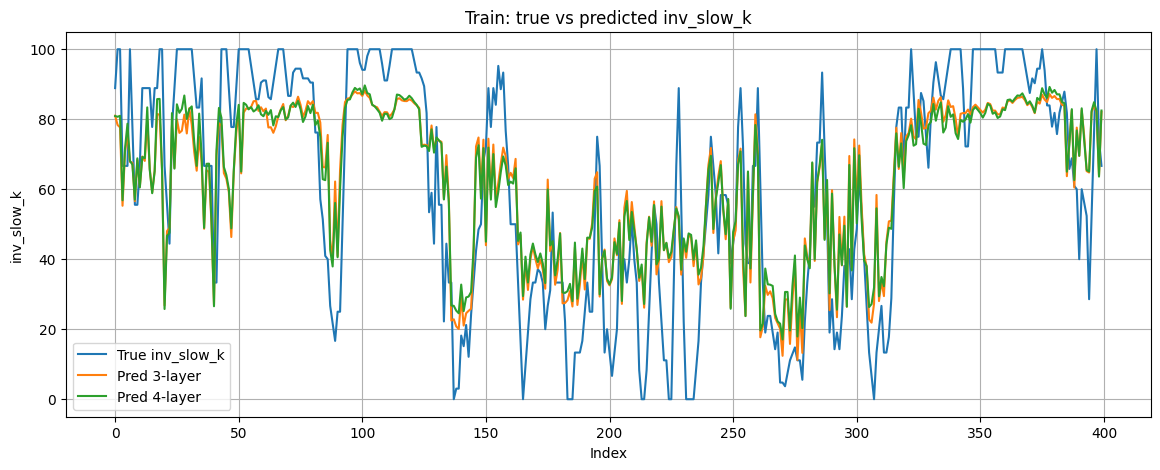

In [47]:
plot_k_predictions(
    yk_train,
    train_pred_3,
    train_pred_4,
    title="Train: true vs predicted inv_slow_k",
    filename="train.png"
)

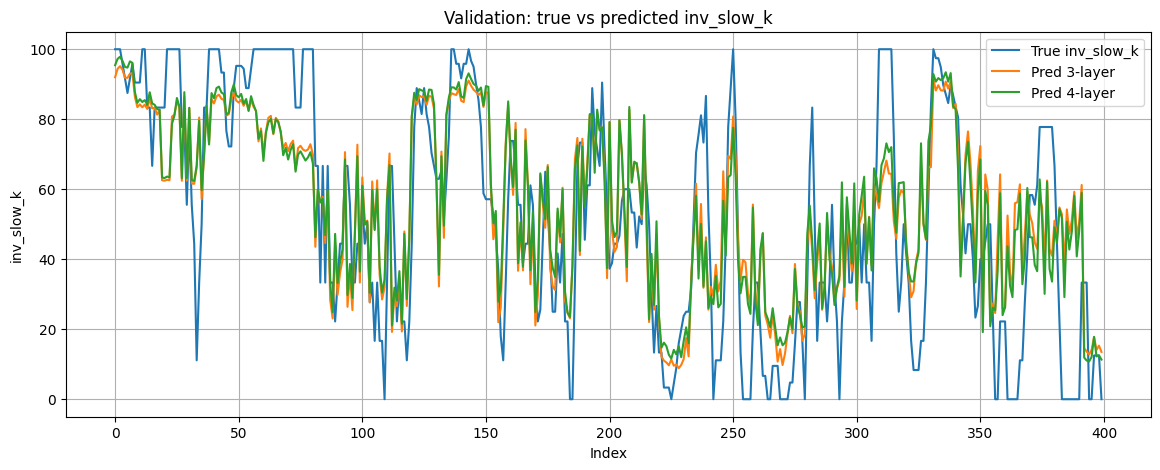

In [48]:
plot_k_predictions(
    yk_val,
    val_pred_3,
    val_pred_4,
    title="Validation: true vs predicted inv_slow_k",
    filename="val.png"
)

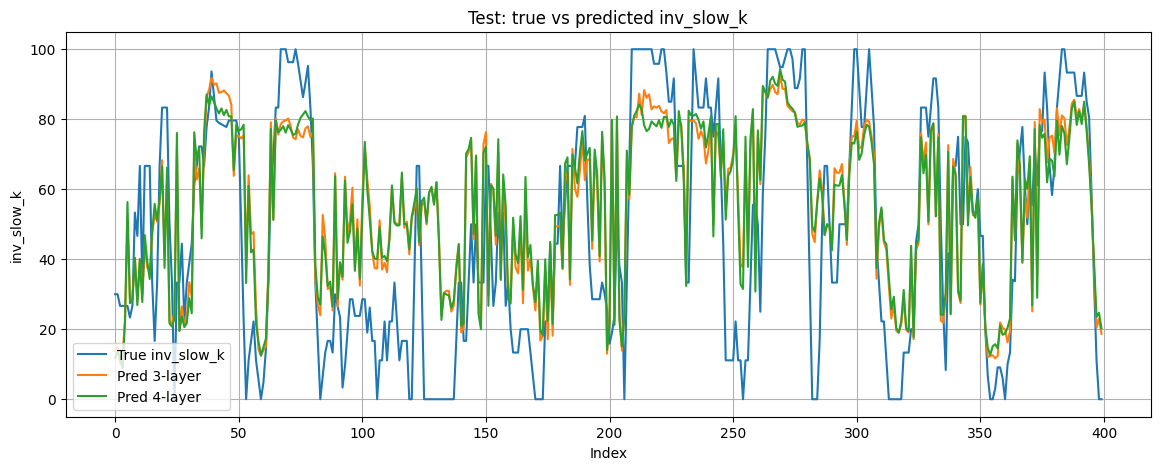

In [49]:
plot_k_predictions(
    yk_test,
    test_pred_3,
    test_pred_4,
    title="Test: true vs predicted inv_slow_k",
    filename="test.png"
)